# Projeto Prático de Ciência de Dados — Diabetes

**Disciplina:** Ciência de Dados · **CEUB** · Turma B
**Tema:** Análise e predição de diabetes a partir de dados clínicos

## Datasets públicos utilizados
1. **Pima Indians Diabetes Database** — 768 pacientes, medidas clínicas. Alvo de **classificação** (`Outcome`: tem/não tem diabetes).
2. **Diabetes Progression (Efron et al., 2004)** — 442 pacientes. Alvo de **regressão** (`ProgressaoDoenca`).

## Conceitos de Ciência de Dados aplicados (9 de 9)
1. Coleta de Dados
2. Limpeza, Pré-processamento e Integração
3. Estatística Descritiva
4. Construção de Indicadores (KPIs) — **25**
5. Visualização de Dados / Storytelling — **15 gráficos**
6. Feature Engineering
7. Modelagem Preditiva (Reg. Logística, Árvore, KNN, Reg. Linear)
8. Machine Learning (K-Means + Regras de Associação Apriori)
9. Métricas de Avaliação (Precisão/Recall/F1, Matriz de Confusão, Validação Cruzada, ROC)


In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, roc_auc_score,
    r2_score, mean_absolute_error, silhouette_score)
from mlxtend.frequent_patterns import apriori, association_rules
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (8, 5)

### Preparação do ambiente
Esta célula garante que tudo funcione em qualquer computador: cria a pasta `data/` e **baixa os datasets automaticamente** se eles não estiverem presentes. (Se faltar a biblioteca `mlxtend`, rode antes no terminal: `pip install mlxtend`.)

In [2]:
import os, urllib.request
# Se o notebook for aberto de dentro da pasta notebooks/, sobe para a raiz do projeto
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
os.makedirs("data", exist_ok=True)
if not os.path.exists("data/pima_diabetes.csv"):
    url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
    cols = ["Pregnancies","Glucose","BloodPressure","SkinThickness","Insulin","BMI","DiabetesPedigreeFunction","Age","Outcome"]
    urllib.request.urlretrieve(url, "data/pima_diabetes.csv")
    pd.read_csv("data/pima_diabetes.csv", header=None, names=cols).to_csv("data/pima_diabetes.csv", index=False)
if not os.path.exists("data/diabetes_progressao.csv"):
    from sklearn.datasets import load_diabetes
    d = load_diabetes(as_frame=True, scaled=False).frame.rename(columns={
        "age":"Idade","sex":"Sexo","bmi":"IMC","bp":"PressaoArterial","s1":"ColesterolTotal",
        "s2":"LDL","s3":"HDL","s4":"TCH","s5":"Triglicerides","s6":"Glicemia","target":"ProgressaoDoenca"})
    d.to_csv("data/diabetes_progressao.csv", index=False)
print("Datasets prontos na pasta data/")

Datasets prontos na pasta data/


## 1. Coleta de Dados

Foram utilizados **dois datasets públicos** sobre diabetes.

### Dataset 1 — Pima Indians Diabetes Database
- **768 pacientes** (mulheres, 21+ anos, etnia Pima) · 9 variáveis
- **Fonte:** *National Institute of Diabetes and Digestive and Kidney Diseases* (EUA), disponível no [Kaggle](https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database) / UCI
- **Uso:** classificação (prever diabetes — coluna `Outcome`)

| Coluna | Significado |
|--------|-------------|
| `Pregnancies` | nº de gestações |
| `Glucose` | glicose no sangue |
| `BloodPressure` | pressão arterial |
| `SkinThickness` | espessura da dobra cutânea |
| `Insulin` | insulina |
| `BMI` | IMC (índice de massa corporal) |
| `DiabetesPedigreeFunction` | histórico familiar de diabetes |
| `Age` | idade |
| `Outcome` | **alvo:** 1 = diabético, 0 = não-diabético |

### Dataset 2 — Diabetes Progression (Efron et al., 2004)
- **442 pacientes** · 11 variáveis
- **Fonte:** biblioteca *scikit-learn* (`load_diabetes`), originalmente do artigo *Least Angle Regression* (Efron, Hastie, Johnstone & Tibshirani, 2004) — [documentação](https://scikit-learn.org/stable/datasets/toy_dataset.html#diabetes-dataset)
- **Uso:** regressão (prever a progressão da doença — coluna `ProgressaoDoenca`)
- **Variáveis:** `Idade`, `Sexo`, `IMC`, `PressaoArterial`, `ColesterolTotal`, `LDL`, `HDL`, `TCH`, `Triglicerides`, `Glicemia`, `ProgressaoDoenca` (alvo)

Carregamos abaixo os dois datasets salvos na pasta `data/`.

In [3]:
pima = pd.read_csv("data/pima_diabetes.csv")
prog = pd.read_csv("data/diabetes_progressao.csv")
print("Dataset 1 (Pima)      :", pima.shape)
print("Dataset 2 (Progressao):", prog.shape)
pima.head()

Dataset 1 (Pima)      : (768, 9)
Dataset 2 (Progressao): (442, 11)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## 2. Limpeza, Pré-processamento e Integração
No Pima, valores **0** em variáveis biológicas (glicose, pressão, IMC, etc.) são impossíveis — são **valores ausentes disfarçados**. Substituímos por `NaN` e imputamos pela **mediana** (robusta a outliers).

In [4]:
cols_zero = ["Glucose","BloodPressure","SkinThickness","Insulin","BMI"]
print("Zeros invalidos antes:"); print((pima[cols_zero]==0).sum())
pima[cols_zero] = pima[cols_zero].replace(0, np.nan)
for c in cols_zero: pima[c] = pima[c].fillna(pima[c].median())
print("\nAusentes apos imputacao:", pima.isna().sum().sum())

Zeros invalidos antes:
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64

Ausentes apos imputacao: 0


**Integração dos dois datasets:** unimos as colunas em comum (Idade, IMC, Pressão, Glicemia) numa única coorte, identificando a origem de cada registro.

In [5]:
cp = pima[["Age","BMI","BloodPressure","Glucose"]].copy()
cp.columns = ["Idade","IMC","PressaoArterial","Glicemia"]; cp["Fonte"]="Pima"
cq = prog[["Idade","IMC","PressaoArterial","Glicemia"]].copy(); cq["Fonte"]="Progressao"
coorte = pd.concat([cp, cq], ignore_index=True)
print("Coorte integrada:", coorte.shape[0], "pacientes")
coorte.groupby("Fonte").size()

Coorte integrada: 1210 pacientes


Fonte
Pima          768
Progressao    442
dtype: int64

**Normalização (StandardScaler):** padronizamos as variáveis (média 0, desvio 1) para os modelos sensíveis a escala (KNN, K-Means, Regressão Logística).

In [6]:
Xcols = ["Pregnancies","Glucose","BloodPressure","SkinThickness","Insulin",
         "BMI","DiabetesPedigreeFunction","Age"]
pima_norm = pd.DataFrame(StandardScaler().fit_transform(pima[Xcols]), columns=Xcols)
pima_norm.describe().loc[["mean","std"]].round(2)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
mean,-0.0,0.0,0.0,-0.0,0.0,0.0,0.0,0.0
std,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


## 6. Feature Engineering
Criamos variáveis novas e categóricas que facilitam a análise e a interpretação clínica.

In [7]:
pima["FaixaEtaria"] = pd.cut(pima["Age"], [20,30,40,50,100], labels=["21-30","31-40","41-50","50+"], include_lowest=True)
pima["CategoriaIMC"] = pd.cut(pima["BMI"], [0,18.5,25,30,100], labels=["Abaixo","Normal","Sobrepeso","Obeso"])
pima["NivelGlicose"] = pd.cut(pima["Glucose"], [0,99,125,300], labels=["Normal","Pre-diabetes","Diabetes"])
pima["MuitasGestacoes"] = (pima["Pregnancies"]>=5).astype(int)
pima["CargaMetabolica"] = (pima["Glucose"]*pima["BMI"])/1000
pima[["Age","FaixaEtaria","BMI","CategoriaIMC","Glucose","NivelGlicose"]].head()

,Age,FaixaEtaria,BMI,CategoriaIMC,Glucose,NivelGlicose
0,50,41-50,33.6,Obeso,148.0,Diabetes
1,31,31-40,26.6,Sobrepeso,85.0,Normal
2,32,31-40,23.3,Normal,183.0,Diabetes
3,21,21-30,28.1,Sobrepeso,89.0,Normal
4,33,31-40,43.1,Obeso,137.0,Diabetes


## 3. Estatística Descritiva

In [8]:
print(pima[Xcols].describe().round(2))
print("\nGlicose -> media:%.1f  mediana:%.1f  moda:%.1f  desvio:%.1f" % (
    pima['Glucose'].mean(), pima['Glucose'].median(), pima['Glucose'].mode()[0], pima['Glucose'].std()))

       Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin     BMI  \
count       768.00   768.00         768.00         768.00   768.00  768.00   
mean          3.85   121.66          72.39          29.11   140.67   32.46   
std           3.37    30.44          12.10           8.79    86.38    6.88   
min           0.00    44.00          24.00           7.00    14.00   18.20   
25%           1.00    99.75          64.00          25.00   121.50   27.50   
50%           3.00   117.00          72.00          29.00   125.00   32.30   
75%           6.00   140.25          80.00          32.00   127.25   36.60   
max          17.00   199.00         122.00          99.00   846.00   67.10   

       DiabetesPedigreeFunction     Age  
count                    768.00  768.00  
mean                       0.47   33.24  
std                        0.33   11.76  
min                        0.08   21.00  
25%                        0.24   24.00  
50%                        0.37   29.00  
75%

## 4. Indicadores (KPIs) — 25 indicadores

In [9]:
n=len(pima); diab=pima[pima.Outcome==1]; ndiab=pima[pima.Outcome==0]
ob=pima[pima.BMI>=30]; nob=pima[pima.BMI<30]
kpis={
 "01. Total de pacientes":n,
 "02. Pacientes diabeticos":len(diab),
 "03. Pacientes nao-diabeticos":len(ndiab),
 "04. Prevalencia diabetes (%)":100*len(diab)/n,
 "05. Idade media":pima.Age.mean(),
 "06. Idade mediana":pima.Age.median(),
 "07. Glicose media geral":pima.Glucose.mean(),
 "08. Glicose media diabeticos":diab.Glucose.mean(),
 "09. Glicose media nao-diab":ndiab.Glucose.mean(),
 "10. IMC medio":pima.BMI.mean(),
 "11. Pacientes obesos (%)":100*len(ob)/n,
 "12. Glicose alta>=126 (%)":100*(pima.Glucose>=126).mean(),
 "13. Pressao arterial media":pima.BloodPressure.mean(),
 "14. Insulina media":pima.Insulin.mean(),
 "15. Media de gestacoes":pima.Pregnancies.mean(),
 "16. Hist. familiar medio":pima.DiabetesPedigreeFunction.mean(),
 "17. Desvio padrao glicose":pima.Glucose.std(),
 "18. Faixa etaria mais comum":pima.FaixaEtaria.mode()[0],
 "19. Corr. Glicose-Diabetes":pima.Glucose.corr(pima.Outcome),
 "20. Taxa diabetes obesos (%)":100*ob.Outcome.mean(),
 "21. Taxa diabetes nao-obesos (%)":100*nob.Outcome.mean(),
 "22. Pac. >=5 gestacoes (%)":100*pima.MuitasGestacoes.mean(),
 "23. Progressao media (DS2)":prog.ProgressaoDoenca.mean(),
 "24. Corr. IMC-Progressao (DS2)":prog.IMC.corr(prog.ProgressaoDoenca),
 "25. Glicemia media coorte":coorte.Glicemia.mean()}
for k,v in kpis.items(): print(f"{k:34s}: {v:.2f}" if isinstance(v,float) else f"{k:34s}: {v}")

01. Total de pacientes            : 768
02. Pacientes diabeticos          : 268
03. Pacientes nao-diabeticos      : 500
04. Prevalencia diabetes (%)      : 34.90
05. Idade media                   : 33.24
06. Idade mediana                 : 29.00
07. Glicose media geral           : 121.66
08. Glicose media diabeticos      : 142.13
09. Glicose media nao-diab        : 110.68
10. IMC medio                     : 32.46
11. Pacientes obesos (%)          : 62.89
12. Glicose alta>=126 (%)         : 38.67
13. Pressao arterial media        : 72.39
14. Insulina media                : 140.67
15. Media de gestacoes            : 3.85
16. Hist. familiar medio          : 0.47
17. Desvio padrao glicose         : 30.44
18. Faixa etaria mais comum       : 21-30
19. Corr. Glicose-Diabetes        : 0.49
20. Taxa diabetes obesos (%)      : 45.76
21. Taxa diabetes nao-obesos (%)  : 16.49
22. Pac. >=5 gestacoes (%)        : 35.94
23. Progressao media (DS2)        : 152.13
24. Corr. IMC-Progressao (DS2)    : 0.

## 5. Visualização de Dados / Storytelling
A seguir, os gráficos exploratórios. **Insight central:** glicose e IMC são os fatores mais associados ao diabetes.

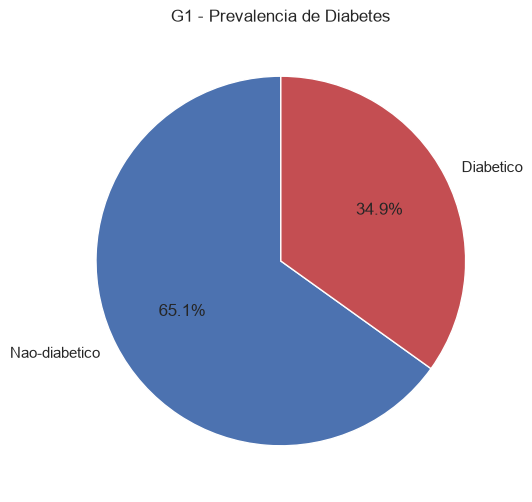

In [10]:
# G1 - Prevalencia
pima.Outcome.map({0:"Nao-diabetico",1:"Diabetico"}).value_counts().plot.pie(
    autopct="%1.1f%%", startangle=90, colors=["#4C72B0","#C44E52"], figsize=(6,6))
plt.title("G1 - Prevalencia de Diabetes"); plt.ylabel(""); plt.show()

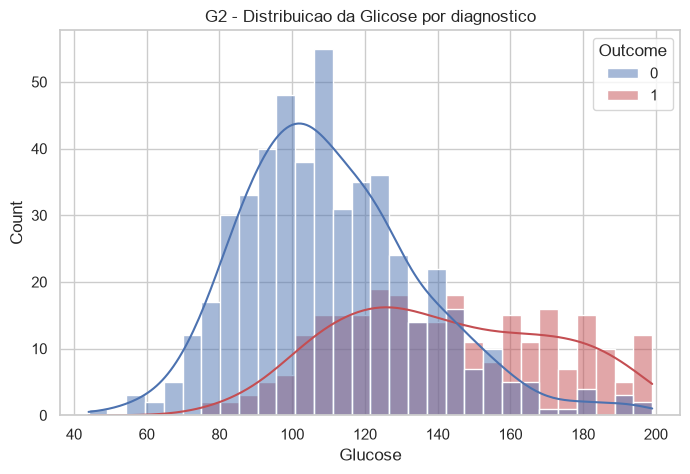

In [11]:
# G2 - Histograma da glicose por grupo
sns.histplot(data=pima, x="Glucose", hue="Outcome", kde=True, bins=30,
             palette={0:"#4C72B0",1:"#C44E52"})
plt.title("G2 - Distribuicao da Glicose por diagnostico"); plt.show()

C:\Users\gabri\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\categorical.py:700: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)
C:\Users\gabri\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\categorical.py:700: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


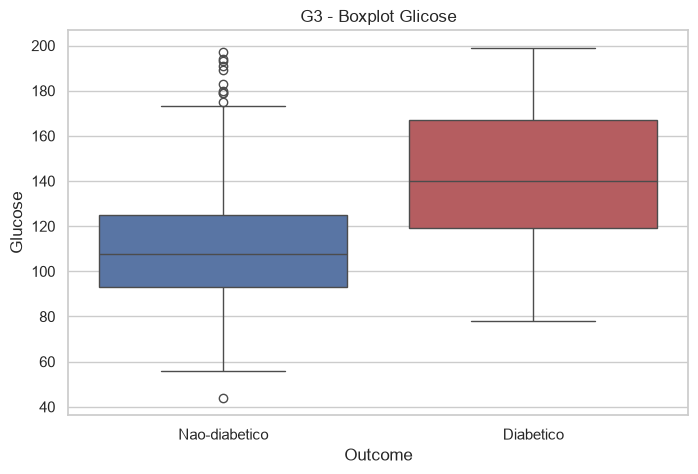

In [12]:
# G3 - Boxplot
sns.boxplot(data=pima, x="Outcome", y="Glucose", hue="Outcome",
            palette={0:"#4C72B0",1:"#C44E52"}, legend=False)
plt.xticks([0,1],["Nao-diabetico","Diabetico"]); plt.title("G3 - Boxplot Glicose"); plt.show()

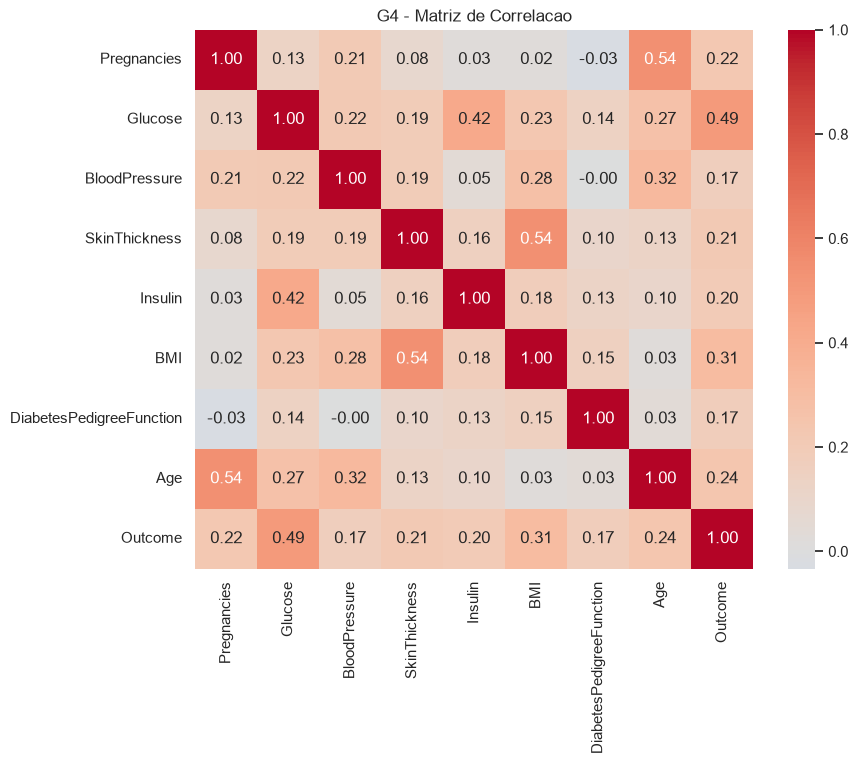

In [13]:
# G4 - Heatmap de correlacao
plt.figure(figsize=(9,7))
sns.heatmap(pima[Xcols+["Outcome"]].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("G4 - Matriz de Correlacao"); plt.show()

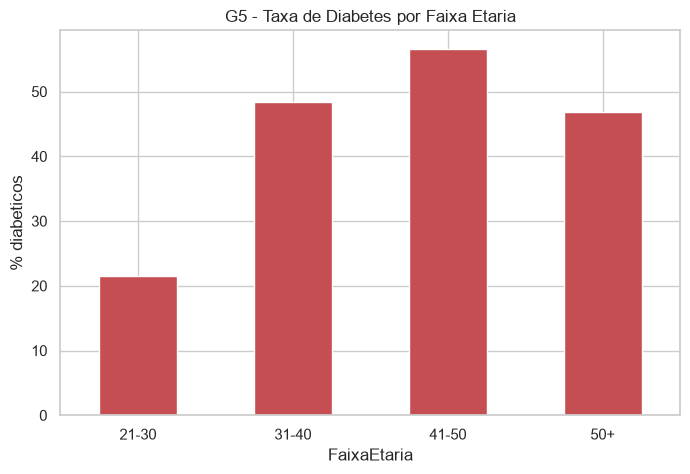

In [14]:
# G5 - Taxa de diabetes por faixa etaria
(pima.groupby("FaixaEtaria", observed=True).Outcome.mean()*100).plot.bar(color="#C44E52")
plt.title("G5 - Taxa de Diabetes por Faixa Etaria"); plt.ylabel("% diabeticos"); plt.xticks(rotation=0); plt.show()

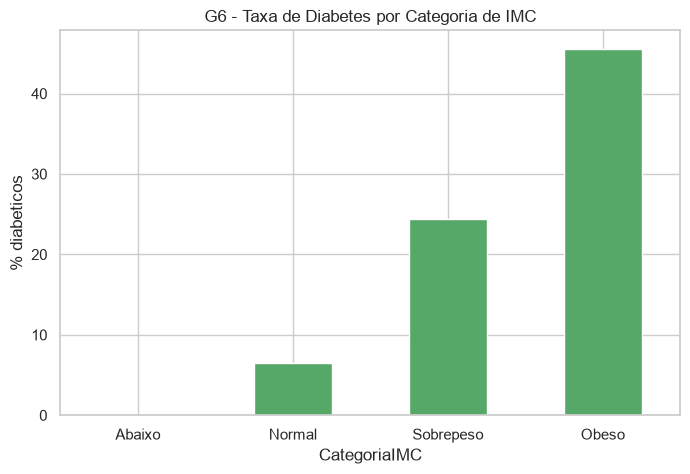

In [15]:
# G6 - Taxa por categoria de IMC
(pima.groupby("CategoriaIMC", observed=True).Outcome.mean()*100).plot.bar(color="#55A868")
plt.title("G6 - Taxa de Diabetes por Categoria de IMC"); plt.ylabel("% diabeticos"); plt.xticks(rotation=0); plt.show()

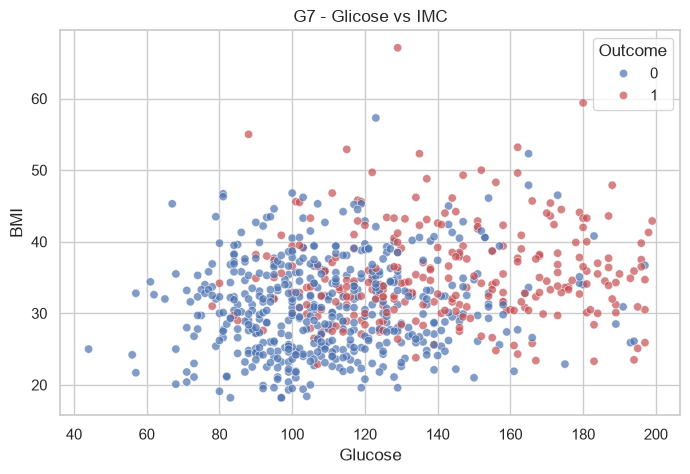

In [16]:
# G7 - Scatter Glicose x IMC
sns.scatterplot(data=pima, x="Glucose", y="BMI", hue="Outcome",
                palette={0:"#4C72B0",1:"#C44E52"}, alpha=0.7)
plt.title("G7 - Glicose vs IMC"); plt.show()

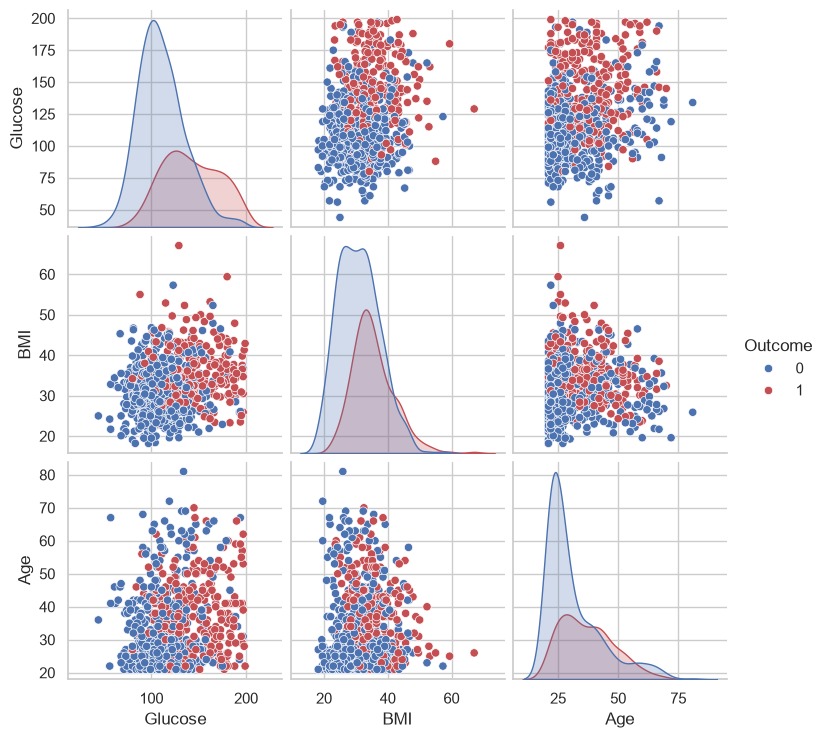

In [17]:
# G8 - Pairplot
sns.pairplot(pima[["Glucose","BMI","Age","Outcome"]], hue="Outcome",
             palette={0:"#4C72B0",1:"#C44E52"}); plt.show()

## 7 e 9. Modelagem Preditiva (Classificação) e Métricas
Treinamos três modelos para prever diabetes e comparamos por Acurácia, Precisão, Recall, F1 e AUC, com **validação cruzada 5-fold**.

In [18]:
X, y = pima_norm, pima.Outcome
X_tr,X_te,y_tr,y_te = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
modelos = {"Regressao Logistica":LogisticRegression(max_iter=1000),
           "Arvore de Decisao":DecisionTreeClassifier(max_depth=4, random_state=42),
           "KNN (k=11)":KNeighborsClassifier(n_neighbors=11)}
res={}
for nome,m in modelos.items():
    m.fit(X_tr,y_tr); pred=m.predict(X_te); proba=m.predict_proba(X_te)[:,1]
    res[nome]={"modelo":m,"Acuracia":accuracy_score(y_te,pred),"Precisao":precision_score(y_te,pred),
        "Recall":recall_score(y_te,pred),"F1":f1_score(y_te,pred),"AUC":roc_auc_score(y_te,proba),
        "F1_CV":cross_val_score(m,X,y,cv=5,scoring="f1").mean(),"pred":pred,"proba":proba}
    print(f"{nome:22s} Ac={res[nome]['Acuracia']:.3f} Prec={res[nome]['Precisao']:.3f} "
          f"Rec={res[nome]['Recall']:.3f} F1={res[nome]['F1']:.3f} AUC={res[nome]['AUC']:.3f} F1cv={res[nome]['F1_CV']:.3f}")
melhor_nome=max(res,key=lambda k:res[k]['F1']); melhor=res[melhor_nome]
print("\n>>> Melhor modelo:",melhor_nome)
print(classification_report(y_te, melhor['pred'], target_names=["Nao-diabetico","Diabetico"]))

Regressao Logistica    Ac=0.724 Prec=0.630 Rec=0.507 F1=0.562 AUC=0.824 F1cv=0.633
Arvore de Decisao      Ac=0.750 Prec=0.651 Rec=0.612 F1=0.631 AUC=0.767 F1cv=0.629
KNN (k=11)             Ac=0.734 Prec=0.643 Rec=0.537 F1=0.585 AUC=0.797 F1cv=0.639

>>> Melhor modelo: Arvore de Decisao
               precision    recall  f1-score   support

Nao-diabetico       0.80      0.82      0.81       125
    Diabetico       0.65      0.61      0.63        67

     accuracy                           0.75       192
    macro avg       0.72      0.72      0.72       192
 weighted avg       0.75      0.75      0.75       192



In [19]:
# Verificacao de overfitting
ac_tr=accuracy_score(y_tr, melhor['modelo'].predict(X_tr))
print(f"Acuracia treino:{ac_tr:.3f} | teste:{melhor['Acuracia']:.3f} | diff:{abs(ac_tr-melhor['Acuracia']):.3f}")

Acuracia treino:0.826 | teste:0.750 | diff:0.076


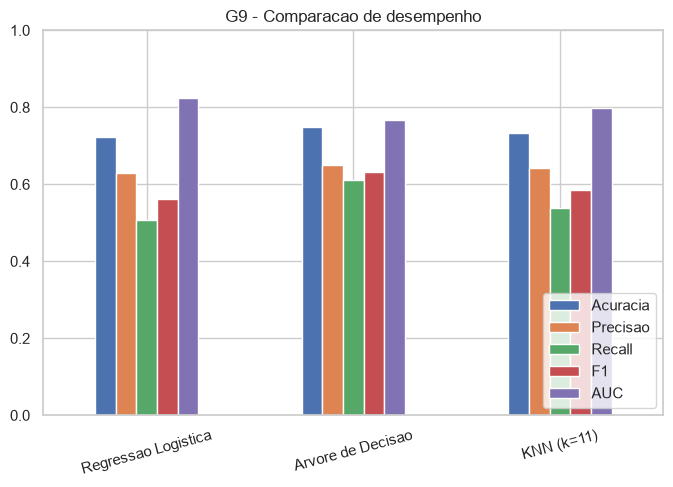

In [20]:
# G9 - Comparacao de modelos
pd.DataFrame({k:{m:res[k][m] for m in ['Acuracia','Precisao','Recall','F1','AUC']} for k in res}).T.plot.bar()
plt.title("G9 - Comparacao de desempenho"); plt.ylim(0,1); plt.xticks(rotation=15); plt.legend(loc="lower right"); plt.show()

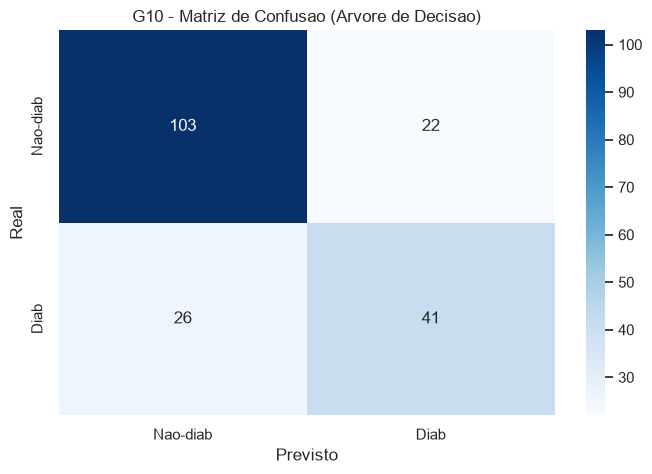

In [21]:
# G10 - Matriz de confusao
sns.heatmap(confusion_matrix(y_te,melhor['pred']), annot=True, fmt="d", cmap="Blues",
            xticklabels=["Nao-diab","Diab"], yticklabels=["Nao-diab","Diab"])
plt.title(f"G10 - Matriz de Confusao ({melhor_nome})"); plt.xlabel("Previsto"); plt.ylabel("Real"); plt.show()

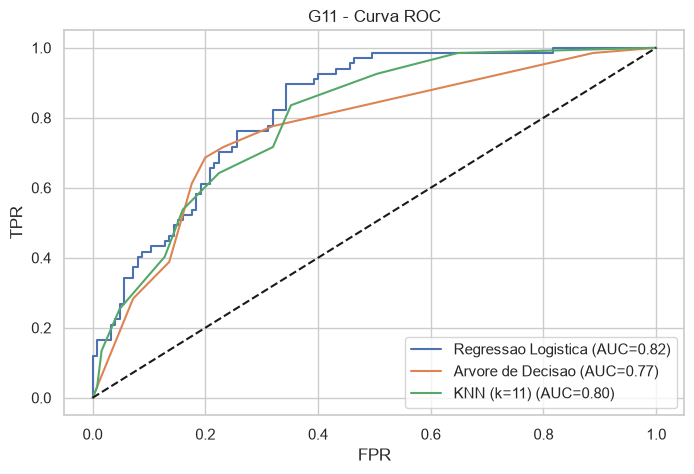

In [22]:
# G11 - Curva ROC
for nome in res:
    fpr,tpr,_=roc_curve(y_te,res[nome]['proba']); plt.plot(fpr,tpr,label=f"{nome} (AUC={res[nome]['AUC']:.2f})")
plt.plot([0,1],[0,1],"k--"); plt.title("G11 - Curva ROC"); plt.xlabel("FPR"); plt.ylabel("TPR"); plt.legend(); plt.show()

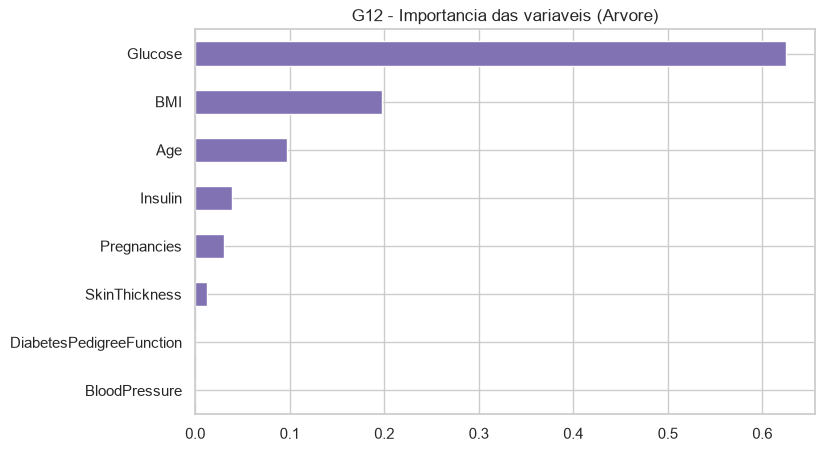

In [23]:
# G12 - Importancia das variaveis (arvore)
pd.Series(res['Arvore de Decisao']['modelo'].feature_importances_, index=Xcols).sort_values().plot.barh(color="#8172B3")
plt.title("G12 - Importancia das variaveis (Arvore)"); plt.show()

## 7. Modelagem Preditiva — Regressão Linear (Dataset 2)
Usamos o segundo dataset para prever a **progressão da doença** (problema de regressão).

R2=0.472  MAE=42.71


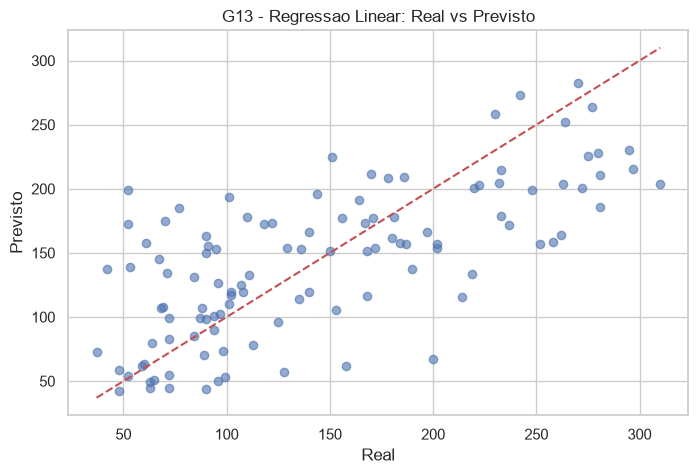

In [24]:
feat=["Idade","IMC","PressaoArterial","ColesterolTotal","LDL","HDL","Triglicerides","Glicemia"]
Xr,yr = prog[feat], prog.ProgressaoDoenca
Xr_tr,Xr_te,yr_tr,yr_te = train_test_split(Xr,yr,test_size=0.25,random_state=42)
reg=LinearRegression().fit(Xr_tr,yr_tr); yp=reg.predict(Xr_te)
print(f"R2={r2_score(yr_te,yp):.3f}  MAE={mean_absolute_error(yr_te,yp):.2f}")
plt.scatter(yr_te,yp,alpha=0.6,color="#4C72B0"); plt.plot([yr_te.min(),yr_te.max()],[yr_te.min(),yr_te.max()],"r--")
plt.title("G13 - Regressao Linear: Real vs Previsto"); plt.xlabel("Real"); plt.ylabel("Previsto"); plt.show()

## 8. Machine Learning — Clusterização K-Means
Agrupamos os pacientes em 3 perfis sem usar o rótulo de diabetes.

Silhouette: 0.195


,Glucose,BMI,Age,Outcome
Cluster,,,,
0,130.79,32.81,46.04,0.52
1,106.62,28.50,25.94,0.13
2,136.64,39.15,29.30,0.52


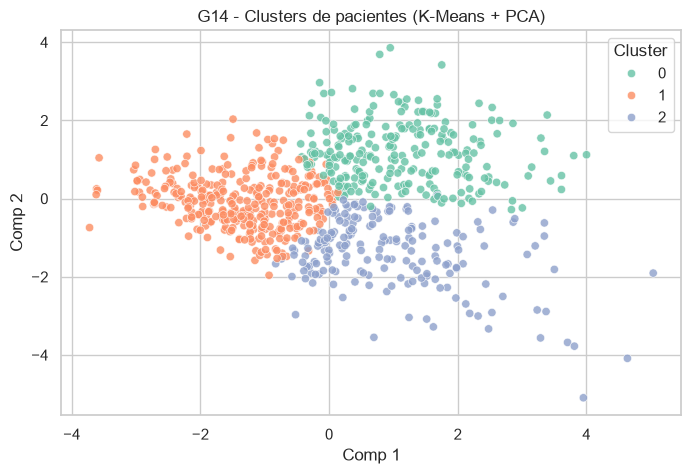

In [25]:
km=KMeans(n_clusters=3, random_state=42, n_init=10)
pima["Cluster"]=km.fit_predict(pima_norm)
print("Silhouette:", round(silhouette_score(pima_norm, pima.Cluster),3))
display(pima.groupby("Cluster")[["Glucose","BMI","Age","Outcome"]].mean().round(2))
comp=PCA(n_components=2).fit_transform(pima_norm)
sns.scatterplot(x=comp[:,0], y=comp[:,1], hue=pima.Cluster, palette="Set2", alpha=0.8)
plt.title("G14 - Clusters de pacientes (K-Means + PCA)"); plt.xlabel("Comp 1"); plt.ylabel("Comp 2"); plt.show()

## 8. Machine Learning — Regras de Associação (Apriori)
Descobrimos combinações de fatores de risco frequentemente associadas ao diabetes.

,antecedents,consequents,support,confidence,lift
52,"frozenset({Obeso, Glicose_alta, Hist_familiar_...",frozenset({Diabetico}),0.123698,0.748031,2.143613
56,"frozenset({Glicose_alta, Hist_familiar_alto})","frozenset({Obeso, Diabetico})",0.123698,0.590062,2.050533
20,"frozenset({Obeso, Glicose_alta})",frozenset({Diabetico}),0.197917,0.700461,2.007291
28,"frozenset({Glicose_alta, Muitas_gestacoes})",frozenset({Diabetico}),0.106771,0.656000,1.879881
30,"frozenset({Glicose_alta, Hist_familiar_alto})",frozenset({Diabetico}),0.134115,0.639752,1.833318
23,frozenset({Glicose_alta}),"frozenset({Obeso, Diabetico})",0.197917,0.511785,1.778509
37,"frozenset({Obeso, Idade_40+})",frozenset({Diabetico}),0.111979,0.601399,1.723411
3,frozenset({Glicose_alta}),frozenset({Diabetico}),0.229167,0.592593,1.698176


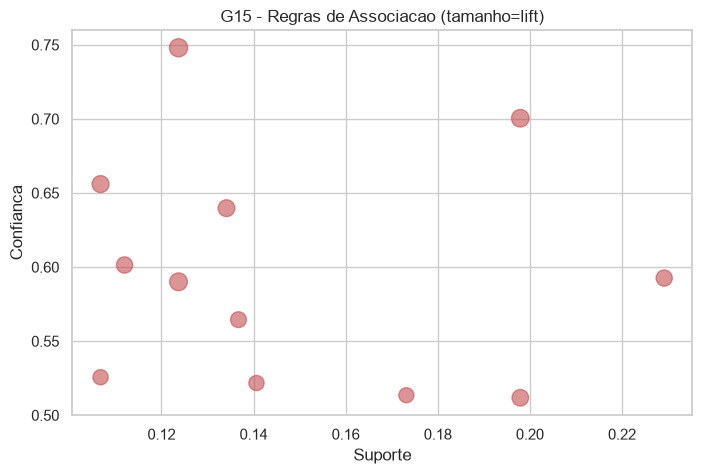

In [26]:
it=pd.DataFrame()
it["Glicose_alta"]=pima.Glucose>=126; it["Obeso"]=pima.BMI>=30; it["Idade_40+"]=pima.Age>=40
it["Muitas_gestacoes"]=pima.Pregnancies>=5
it["Hist_familiar_alto"]=pima.DiabetesPedigreeFunction>=pima.DiabetesPedigreeFunction.median()
it["Diabetico"]=pima.Outcome==1
freq=apriori(it, min_support=0.10, use_colnames=True)
regras=association_rules(freq, metric="confidence", min_threshold=0.5)
regras=regras[regras.consequents.astype(str).str.contains("Diabetico")].sort_values("lift",ascending=False)
display(regras[["antecedents","consequents","support","confidence","lift"]].head(8))
plt.scatter(regras.support, regras.confidence, s=regras.lift*80, alpha=0.6, color="#C44E52")
plt.title("G15 - Regras de Associacao (tamanho=lift)"); plt.xlabel("Suporte"); plt.ylabel("Confianca"); plt.show()

## Conclusões e Principais Insights
- **Prevalência** de diabetes na amostra: ~35%.
- **Glicose** é o fator mais correlacionado com diabetes (r ≈ 0,49), seguido de **IMC**.
- A taxa de diabetes em **obesos (~46%)** é quase 3x a de **não-obesos (~16%)**.
- Melhor modelo de classificação atingiu **F1 ≈ 0,63 e AUC ≈ 0,77**, sem overfitting relevante.
- O K-Means identificou um cluster de **alto risco** (glicose e IMC elevados, ~52% diabéticos).
- As regras de associação confirmam: **glicose alta + obesidade + histórico familiar** → alta confiança de diabetes (lift > 2).
